# <u>Curtailment of Renewables — France</u>

Ce notebook présente l'analyse complète du curtailment des énergies renouvelables en **France** (2024–2025).

**Questions de recherche :**
- *How often* do curtailment events occur?
- *Under which conditions* (prix, réseau, météo) ?
- *For which renewables* (éolien vs solaire) ?

The aim of this notebook is to present the complete analysis conducted for France. We investigate the occurrence of curtailment and negative day-ahead electricity prices in a power system dominated by nuclear with a growing share of renewables. Particular attention is paid to weather conditions, temporal dynamics, and the distinction between wind and solar curtailment.

## <u>1. Necessary imports</u>

In [1]:
from pathlib import Path
import math
import calendar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scripts.data as dl
import scripts.plots as pl

plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
# Country selection — change to 'allemagne' to run the German analysis
COUNTRY = 'france'

## <u>2. Data load and processing</u>

The data for France (Jan 2024 – Dec 2025) are obtained from **energy-charts.info** (ENTSO-E transparency platform).

Sources : génération réelle, consommation, prix day-ahead, prévisions, flux transfrontaliers, capacités installées, météo (Open-Meteo).

Le chargement est centralisé dans `dl.load_data(country)` qui lit les CSV, déduplique les timestamps DST, et applique le mapping de colonnes pour la France.

In [3]:
df_raw = dl.load_data(COUNTRY)
print(f'Données chargées : {df_raw.shape[0]} heures x {df_raw.shape[1]} colonnes')
print(f'Période : {df_raw.index.min()} -> {df_raw.index.max()}')
df_raw.head(3)

Données chargées : 17542 heures x 67 colonnes
Période : 2024-01-01 00:00:00 -> 2025-12-31 23:00:00


,price,load,residual_load_tso,pumped_consumption,wind_on,wind_off,solar,nuclear,hydro_ror,hydro_res,hydro_pumped,gas,coal,oil,biomass,waste,load_forecast,load_forecast_j1,vre_forecast_total,wind_off_forecast,wind_on_forecast,solar_forecast,Belgium (net export) [MWh] Calculated resolutions,Germany (net export) [MWh] Calculated resolutions,Italy (net export) [MWh] Calculated resolutions,...,cap_wind_on,cap_solar,price_de,price_de_lu,Belgium [€/MWh] Calculated resolutions,Denmark 1 [€/MWh] Calculated resolutions,Denmark 2 [€/MWh] Calculated resolutions,France [€/MWh] Calculated resolutions,Netherlands [€/MWh] Calculated resolutions,Norway 2 [€/MWh] Calculated resolutions,Austria [€/MWh] Calculated resolutions,Poland [€/MWh] Calculated resolutions,Sweden 4 [€/MWh] Calculated resolutions,price_ch,Czech Republic [€/MWh] Calculated resolutions,DE/AT/LU [€/MWh] Calculated resolutions,Northern Italy [€/MWh] Calculated resolutions,Slovenia [€/MWh] Calculated resolutions,Hungary [€/MWh] Calculated resolutions,windspeed_10m,windspeed_100m,shortwave_radiation,direct_radiation,temperature_2m,cloudcover
Start date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,0.10,52847.00,37645.00,-2033.00,14399.00,578.00,225.00,40387.00,4822.00,1481.00,0.00,1810.00,15.00,162.00,343.00,87.00,53037.50,54025.00,15290.36,240.00,15050.36,0.00,1513.00,835.00,-2235.00,...,22910.00,22860.00,0.10,21.15,0.10,16.99,29.13,0.10,0.10,53.79,0.10,76.69,29.56,25.97,0.10,NaN,107.09,0.10,0.10,5.44,9.51,0.00,0.00,7.23,74.50
2024-01-01 01:00:00,0.01,51600.00,36866.00,-2067.00,14157.00,577.00,0.00,37528.00,4767.00,1282.00,0.00,1840.00,16.00,191.00,343.00,83.00,51587.50,52837.50,15018.51,240.00,14778.51,0.00,1488.50,90.00,-2102.00,...,22910.00,22860.00,0.01,20.96,0.01,28.14,28.46,0.01,0.01,48.98,0.01,74.50,28.46,21.99,0.01,NaN,104.00,0.01,0.01,5.42,9.45,0.00,0.00,7.08,72.00
2024-01-01 02:00:00,0.00,50992.00,36625.00,-1685.00,13789.00,578.00,0.00,37320.00,4918.00,1005.00,0.00,1787.00,16.00,190.00,343.00,87.00,51112.50,51550.00,14601.58,240.00,14361.58,0.00,1926.00,732.00,-2495.00,...,22910.00,22860.00,0.00,17.73,0.00,26.66,26.66,0.00,0.00,27.45,0.02,73.29,26.66,14.32,0.02,NaN,100.00,0.03,0.04,5.12,9.06,0.00,0.00,6.95,81.00


In [4]:
df_raw.columns.tolist()

['price',
 'load',
 'residual_load_tso',
 'pumped_consumption',
 'wind_on',
 'wind_off',
 'solar',
 'nuclear',
 'hydro_ror',
 'hydro_res',
 'hydro_pumped',
 'gas',
 'coal',
 'oil',
 'biomass',
 'waste',
 'load_forecast',
 'load_forecast_j1',
 'vre_forecast_total',
 'wind_off_forecast',
 'wind_on_forecast',
 'solar_forecast',
 'Belgium (net export) [MWh] Calculated resolutions',
 'Germany (net export) [MWh] Calculated resolutions',
 'Italy (net export) [MWh] Calculated resolutions',
 'Spain (net export) [MWh] Calculated resolutions',
 'Switzerland (net export) [MWh] Calculated resolutions',
 'United Kingdom (net export) [MWh] Calculated resolutions',
 'net_export_total',
 'cap_nuclear',
 'cap_hydro_ror',
 'cap_biomass',
 'cap_coal',
 'Fossil oil [MW] Calculated resolutions',
 'cap_gas',
 'Geothermal [MW] Calculated resolutions',
 'cap_hydro_res',
 'cap_hydro_pumped',
 'Marine [MW] Calculated resolutions',
 'Others [MW] Calculated resolutions',
 'Waste [MW] Calculated resolutions',
 'cap

In [5]:
yearly_summary = (
    df_raw.assign(year=df_raw.index.year)
    .groupby('year')
    .agg(
        n_hours=('price', 'size'),
        price_na_share=('price', lambda x: x.isna().mean()),
        neg_price_share=('price', lambda x: (x < 0).mean()),
    )
)
yearly_summary

,n_hours,price_na_share,neg_price_share
year,,,
2024,8783,0.00,0.04
2025,8759,0.00,0.06


Before this stage, the raw data have not yet been processed and may contain duplicates. These duplicates mainly arise from daylight saving time changes (e.g., the transition between summer and winter time). They are handled automatically inside `dl.load_data()` by averaging over duplicate timestamps.

In [6]:
miss = df_raw.isnull().mean().sort_values(ascending=False)
miss[miss > 0].round(4).to_frame('missing_share')

,missing_share
DE/AT/LU [€/MWh] Calculated resolutions,1.00
coal,0.54
biomass,0.00
hydro_res,0.00
waste,0.00
oil,0.00
gas,0.00
hydro_pumped,0.00
hydro_ror,0.00
nuclear,0.00


Note that several columns exhibit a relatively high number of missing values. At this stage, we retain these variables to gain preliminary insights into the data, with the understanding that they may be removed later if deemed uninformative or problematic.

## <u>3. Feature engineering</u>

At this stage, the objective is to construct a clear and interpretable dataset that can be used both for exploratory analysis and for modeling curtailment events. Feature engineering focuses on:
- Aggregating generation by technology (wind total, VRE real total, thermal total, renewable total)
- Building physical indicators: residual load, generation–load balance, capacity factors
- Deriving a **curtailment proxy**: hours where forecast–actual gap > 50 MWh **AND** price < 10 €/MWh
- Encoding time features (hour_sin/cos, is_weekend)

In [7]:
df_final = dl.add_features(df_raw)

keep_cols = [
    # --- Target & Prices ---
    'price', 'is_negative',

    # --- Demand & System State ---
    'load', 'pumped_consumption', 'residual_load_tso',
    'net_export_total', 'generation_load_balance', 'residual_load',

    # --- Generation Real (Actuals) ---
    'nuclear', 'biomass', 'coal', 'gas', 'oil', 'waste',
    'hydro_pumped', 'hydro_ror', 'hydro_res',
    'wind_off', 'wind_on', 'solar',
    'wind_total', 'renewable_total', 'thermal_total', 'vre_real_total',
    
    # --- prices of neighbors ---
    'price_de',
    "price_de_lu",
    'price_ch',

    

    # --- Installed Capacity ---
    'cap_wind_on', 'cap_wind_off', 'cap_solar',
    'cap_biomass', 'cap_nuclear',
    'cap_hydro_ror', 'cap_hydro_res',

    # --- Forecasts ---
    'load_forecast', 'load_forecast_j1',
    'wind_off_forecast', 'wind_on_forecast', 'solar_forecast',
    'vre_forecast_total', 'wind_forecast_total',
    'residual_load_forecast', 'vre_penetration_forecast',

    # --- Curtailment Analysis (Engineered) ---
    'curtailment_raw_gap',
    'curtailment_mwh',
    'is_curtailment_likely',
    'wind_capacity_factor',
    'solar_capacity_factor',

    # --- Time features ---
    'hour_sin', 'hour_cos', 'is_weekend', 'weekday', 'hour',
    
    # --- Weather features ---
    'windspeed_10m', 'windspeed_100m', 'shortwave_radiation',
       'direct_radiation', 'temperature_2m', 'cloudcover',
    'wind_cf_weather', 'solar_cf_weather', 'wind_theoretical_gen',
       'solar_theoretical_gen', 'vre_theoretical_total',
       'curtailment_physical_wind', 'curtailment_physical_solar',
       'curtailment_physical_total', 'curtailment_physical_economic'
    
]

keep_cols = [c for c in keep_cols if c in df_final.columns]
df_model = df_final[keep_cols].copy()
print(f'df_model : {df_model.shape[0]} heures x {df_model.shape[1]} colonnes')
df_model.head(3)

df_model : 17538 heures x 68 colonnes


,price,is_negative,load,pumped_consumption,residual_load_tso,net_export_total,generation_load_balance,residual_load,nuclear,biomass,coal,gas,oil,waste,hydro_pumped,hydro_ror,hydro_res,wind_off,wind_on,solar,wind_total,renewable_total,thermal_total,vre_real_total,price_de,...,curtailment_raw_gap,curtailment_mwh,is_curtailment_likely,wind_capacity_factor,solar_capacity_factor,hour_sin,hour_cos,is_weekend,weekday,hour,windspeed_10m,windspeed_100m,shortwave_radiation,direct_radiation,temperature_2m,cloudcover,wind_cf_weather,solar_cf_weather,wind_theoretical_gen,solar_theoretical_gen,vre_theoretical_total,curtailment_physical_wind,curtailment_physical_solar,curtailment_physical_total,curtailment_physical_economic
Start date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,0.10,0,52847.00,-2033.00,37645.00,-6184.00,11462.00,37645.00,40387.00,343.00,15.00,1810.00,162.00,87.00,0.00,4822.00,1481.00,578.00,14399.00,225.00,14977.00,21935.00,42374.00,15202.00,0.10,...,88.36,88.36,1,0.63,0.01,0.00,1.00,0,0,0,5.44,9.51,0.00,0.00,7.23,74.50,0.49,0.00,11744.01,0.00,11744.01,0.00,0.00,0.00,0.00
2024-01-01 01:00:00,0.01,0,51600.00,-2067.00,36866.00,-6870.50,9184.00,36866.00,37528.00,343.00,16.00,1840.00,191.00,83.00,0.00,4767.00,1282.00,577.00,14157.00,0.00,14734.00,21209.00,39575.00,14734.00,0.01,...,284.51,284.51,1,0.62,0.00,0.26,0.97,0,0,1,5.42,9.45,0.00,0.00,7.08,72.00,0.48,0.00,11490.95,0.00,11490.95,0.00,0.00,0.00,0.00
2024-01-01 02:00:00,0.00,0,50992.00,-1685.00,36625.00,-6493.00,9041.00,36625.00,37320.00,343.00,16.00,1787.00,190.00,87.00,0.00,4918.00,1005.00,578.00,13789.00,0.00,14367.00,20720.00,39313.00,14367.00,0.00,...,234.58,234.58,1,0.60,0.00,0.50,0.87,0,0,2,5.12,9.06,0.00,0.00,6.95,81.00,0.42,0.00,10080.80,0.00,10080.80,0.00,0.00,0.00,0.00


In [8]:
df_model = df_final.loc['2024-01-01 00:00:00':'2026-01-01 00:00:00', keep_cols].copy()

In [9]:
yearly_summary_features = (
    df_model.assign(year=df_model.index.year)
    .groupby('year')
    .agg(
        n_hours=('price', 'size'),
        price_na_share=('price', lambda x: x.isna().mean()),
        neg_price_share=('price', lambda x: (x < 0).mean()),
        curtailment_hours=('is_curtailment_likely', 'sum'),
        curtailment_mwh_total=('curtailment_mwh', 'sum'),
    )
)
yearly_summary_features

,n_hours,price_na_share,neg_price_share,curtailment_hours,curtailment_mwh_total
year,,,,,
2024,8783,0.00,0.04,961,2382297.39
2025,8755,0.00,0.06,987,3026985.38


In [10]:
missing_share = (
    df_model
    .isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame(name='missing_share')
)
missing_share[missing_share['missing_share'] > 0]

,missing_share
coal,0.54
thermal_total,0.54
generation_load_balance,0.54
wind_forecast_total,0.00
wind_on_forecast,0.00
solar_forecast,0.00
residual_load_tso,0.00
residual_load,0.00
load,0.00


# <u>Visualisation and first conclusions</u>

In [11]:
# Est-ce qu'on a trouvé du curtailment ?
n_curtailment = df_model['is_curtailment_likely'].sum()
n_total = len(df_model)
pct = 100 * n_curtailment / n_total
print(f'Heures avec curtailment probable : {int(n_curtailment)} / {n_total} ({pct:.1f}%)')
print(f'Volume total curtailé : {df_model["curtailment_mwh"].sum():,.0f} MWh')
print(f'Volume moyen / heure curtailée : {df_model.loc[df_model["is_curtailment_likely"]==1, "curtailment_mwh"].mean():,.0f} MWh')

# Regarde à quoi ça ressemble quand ça arrive
curtailment_events = df_model[df_model['is_curtailment_likely'] == 1]
show_cols = [c for c in ['price', 'curtailment_mwh', 'wind_on', 'solar', 'vre_forecast_total'] if c in curtailment_events.columns]
print(curtailment_events[show_cols].head(10))

Heures avec curtailment probable : 1948 / 17538 (11.1%)
Volume total curtailé : 5,409,283 MWh
Volume moyen / heure curtailée : 2,777 MWh
                     price  curtailment_mwh  wind_on  solar  \
Start date                                                    
2024-01-01 00:00:00   0.10            88.36 14399.00 225.00   
2024-01-01 01:00:00   0.01           284.51 14157.00   0.00   
2024-01-01 02:00:00   0.00           234.58 13789.00   0.00   
2024-01-01 03:00:00  -0.01           786.37 12816.00   0.00   
2024-01-01 04:00:00  -0.03          5147.28  8031.00   0.00   
2024-01-01 05:00:00  -0.02          4828.23  7678.00   0.00   
2024-01-01 06:00:00  -0.04          4310.88  7520.00   0.00   
2024-01-01 07:00:00  -0.01          4020.27  7142.00   0.00   
2024-01-01 08:00:00   0.00          3548.40  6942.00 246.00   
2024-01-01 10:00:00   0.06            68.68 10525.00 933.00   

                     vre_forecast_total  
Start date                               
2024-01-01 00:00:00   

## Correlation Analysis

Les corrélations positives confirment que le curtailment est intrinsèquement lié à l'abondance des énergies renouvelables et aux signaux de prix du marché. La forte corrélation avec la variable `is_negative` valide l'approche économique : le curtailment agit comme une réponse directe aux prix négatifs.

In [12]:
# Quelles colonnes sont les plus liées au curtailment ?
correlations = df_model.corr(numeric_only=True)['curtailment_mwh'].sort_values(ascending=False)
print('=== Top 10 corrélations POSITIVES ===')
print(correlations.head(10))

=== Top 10 corrélations POSITIVES ===
curtailment_mwh                 1.00
curtailment_raw_gap             0.79
is_negative                     0.77
curtailment_physical_economic   0.74
is_curtailment_likely           0.71
vre_penetration_forecast        0.50
curtailment_physical_total      0.50
curtailment_physical_solar      0.46
vre_theoretical_total           0.42
vre_forecast_total              0.41
Name: curtailment_mwh, dtype: float64


À l'inverse, les corrélations négatives soulignent le rôle déterminant des contraintes physiques et de l'inflexibilité du mix électrique. La variable la plus corrélée négativement, la charge résiduelle (residual_load_forecast), est le principal prédicteur du phénomène : plus la demande résiduelle est élevée, moins il y a de curtailment.

In [13]:
# Les corrélations les plus négatives (les facteurs qui 'empêchent' le curtailment)
print('=== Top 10 corrélations NÉGATIVES ===')
print(correlations.tail(10))

=== Top 10 corrélations NÉGATIVES ===
residual_load            -0.24
thermal_total            -0.27
residual_load_forecast   -0.34
price_de                 -0.35
price_de_lu              -0.36
price                    -0.37
price_ch                 -0.37
nuclear                  -0.38
cap_nuclear                NaN
cap_hydro_res              NaN
Name: curtailment_mwh, dtype: float64


## Weather Data & Correlations

We now enrich the analysis with meteorological data (Open-Meteo historical archive, averaged over representative zones in France).

Variables disponibles : vitesse du vent à 10 m et 100 m, rayonnement solaire (shortwave & direct), température à 2 m, couverture nuageuse.

In [14]:
weather = dl.load_weather(COUNTRY)
print(f'Météo : {weather.shape[0]} heures x {weather.shape[1]} colonnes')
print(f'Période : {weather.index.min()} -> {weather.index.max()}')
weather.describe().round(2)

Météo : 17544 heures x 6 colonnes
Période : 2024-01-01 00:00:00 -> 2025-12-31 23:00:00


,windspeed_10m,windspeed_100m,shortwave_radiation,direct_radiation,temperature_2m,cloudcover
count,17544.00,17544.00,17544.00,17544.00,17544.00,17544.00
mean,3.19,5.47,155.66,98.15,13.38,60.65
std,1.18,1.83,219.55,155.64,6.56,25.67
min,0.71,0.86,0.00,0.00,-3.88,0.00
25%,2.28,4.12,0.00,0.00,8.60,42.50
50%,2.99,5.24,10.50,2.50,12.88,63.83
75%,3.92,6.66,268.75,149.33,17.78,81.67
max,9.02,13.93,905.17,788.83,34.65,100.00


### Heatmap météo × variables énergie

Cette matrice montre les corrélations de Pearson entre chaque variable météo et les principales variables énergétiques (curtailment, prix, production renouvelable, charge résiduelle).

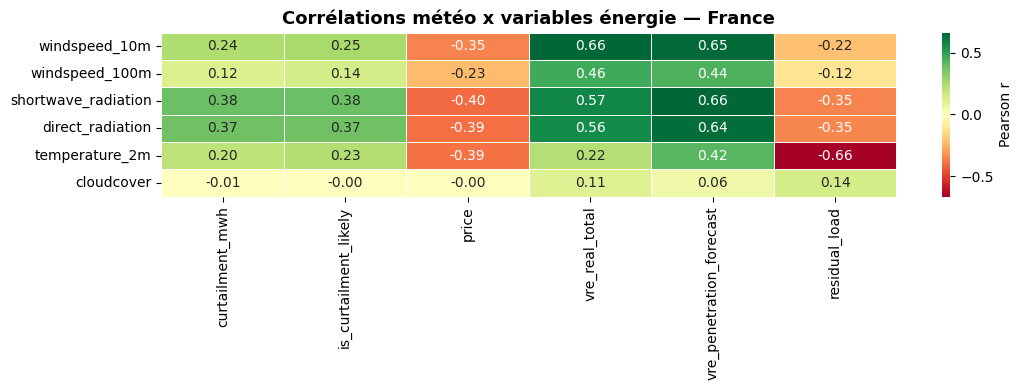

In [15]:
weather_vars = ['windspeed_10m', 'windspeed_100m', 'shortwave_radiation',
       'direct_radiation', 'temperature_2m', 'cloudcover']
energy_targets = [
    c for c in [
        'curtailment_mwh', 'is_curtailment_likely', 'price',
        'vre_real_total', 'vre_penetration_forecast', 'residual_load'
    ]
    if c in df_model.columns
]

cross_corr = (
    df_model[weather_vars + energy_targets]
    .corr(numeric_only=True)
    .loc[weather_vars, energy_targets]
)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    cross_corr, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Pearson r'}
)
ax.set_title(
    f'Corrélations météo x variables énergie — {COUNTRY.capitalize()}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [16]:
weather_corr = df_model[weather_vars + ['curtailment_mwh', 'is_curtailment_likely']].corr(numeric_only=True)

print('=== Corrélations météo -> curtailment_mwh ===')
print(weather_corr['curtailment_mwh'][weather_vars].sort_values(ascending=False).round(3))

print('\n=== Corrélations météo -> is_curtailment_likely ===')
print(weather_corr['is_curtailment_likely'][weather_vars].sort_values(ascending=False).round(3))

=== Corrélations météo -> curtailment_mwh ===
shortwave_radiation    0.38
direct_radiation       0.37
windspeed_10m          0.24
temperature_2m         0.20
windspeed_100m         0.12
cloudcover            -0.01
Name: curtailment_mwh, dtype: float64

=== Corrélations météo -> is_curtailment_likely ===
shortwave_radiation    0.38
direct_radiation       0.38
windspeed_10m          0.25
temperature_2m         0.23
windspeed_100m         0.14
cloudcover            -0.00
Name: is_curtailment_likely, dtype: float64


# <u>Plots</u>

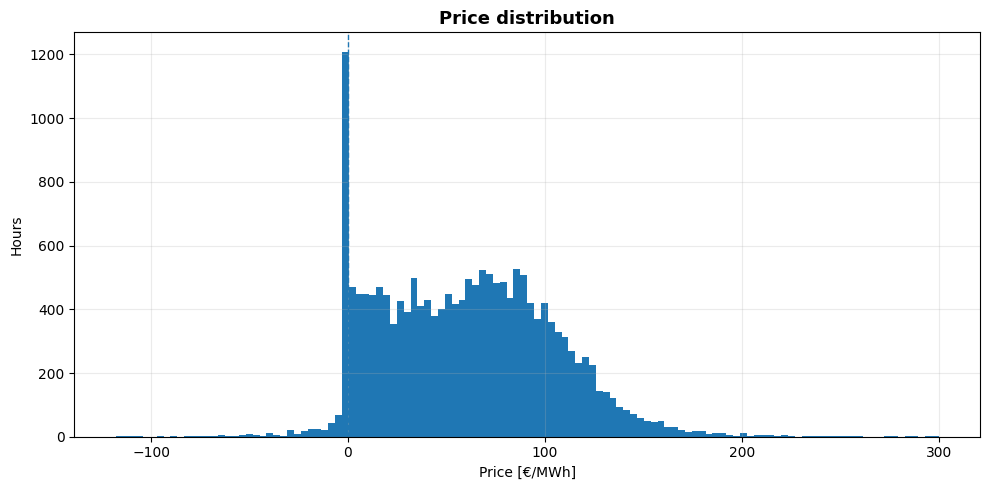

'plots\\curtailment\\france\\price_distribution.png'

In [17]:
# 1. Distribution du prix : Pour montrer la fréquence des prix négatifs (contexte)
pl.plot_price_distribution(df_model, country=COUNTRY)

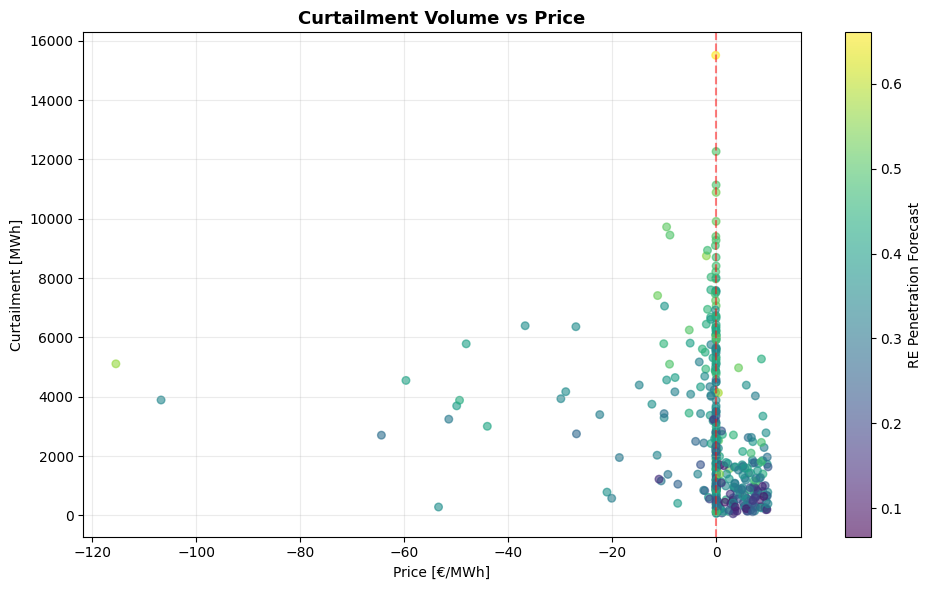

'plots\\curtailment\\france\\curtailment_vs_price.png'

In [18]:
# 2. Corrélation Prix/Curtailment : Pour répondre à 'Under which conditions?' (Économie)
# On s'attend à voir le curtailment exploser quand le prix passe sous 0.
pl.plot_curtailment_v_price_scatter(df_model, country=COUNTRY)

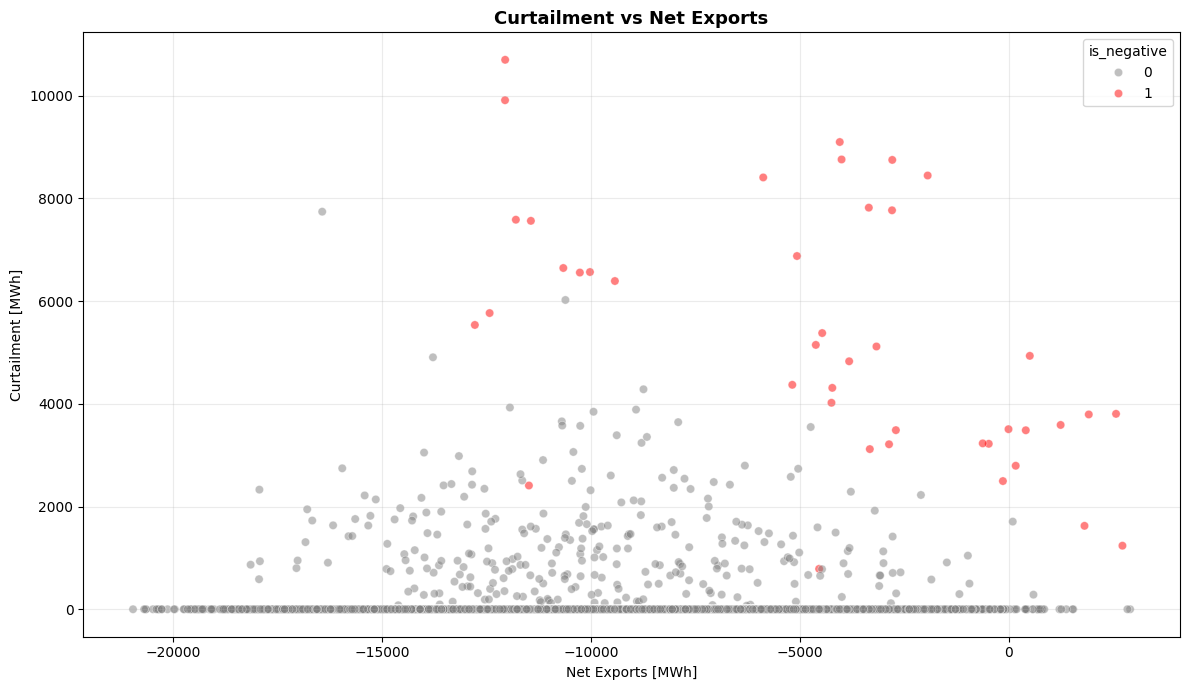

'plots\\curtailment\\france\\export_saturation_logic.png'

In [19]:
# 3. Analyse des Exports : Pour prouver la saturation physique (Réseau)
# On voit si le curtailment n'arrive que quand on exporte déjà au maximum.
pl.plot_export_saturation_curtailment(df_model, country=COUNTRY)

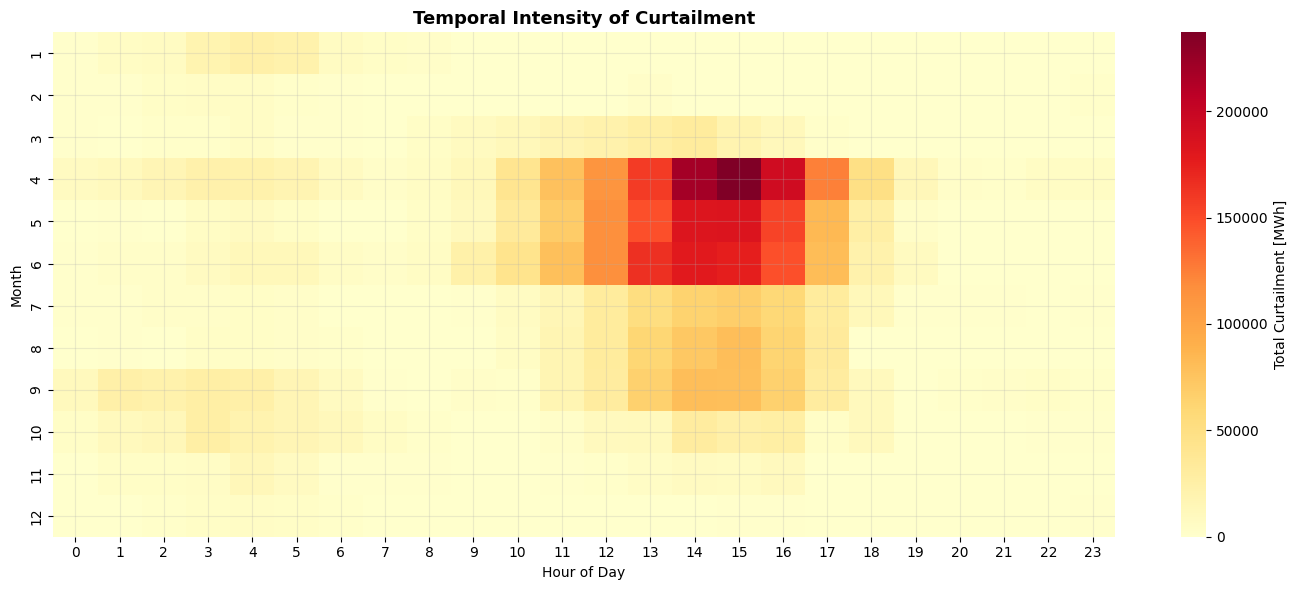

'plots\\curtailment\\france\\curtailment_seasonal_heatmap.png'

In [20]:
# 4. Heatmap saisonnière : Pour répondre à 'How often?' et 'For which renewables?'
# Le solaire apparaîtra l'été à midi, l'éolien l'hiver/nuit.
pl.plot_curtailment_heatmap(df_model, country=COUNTRY)

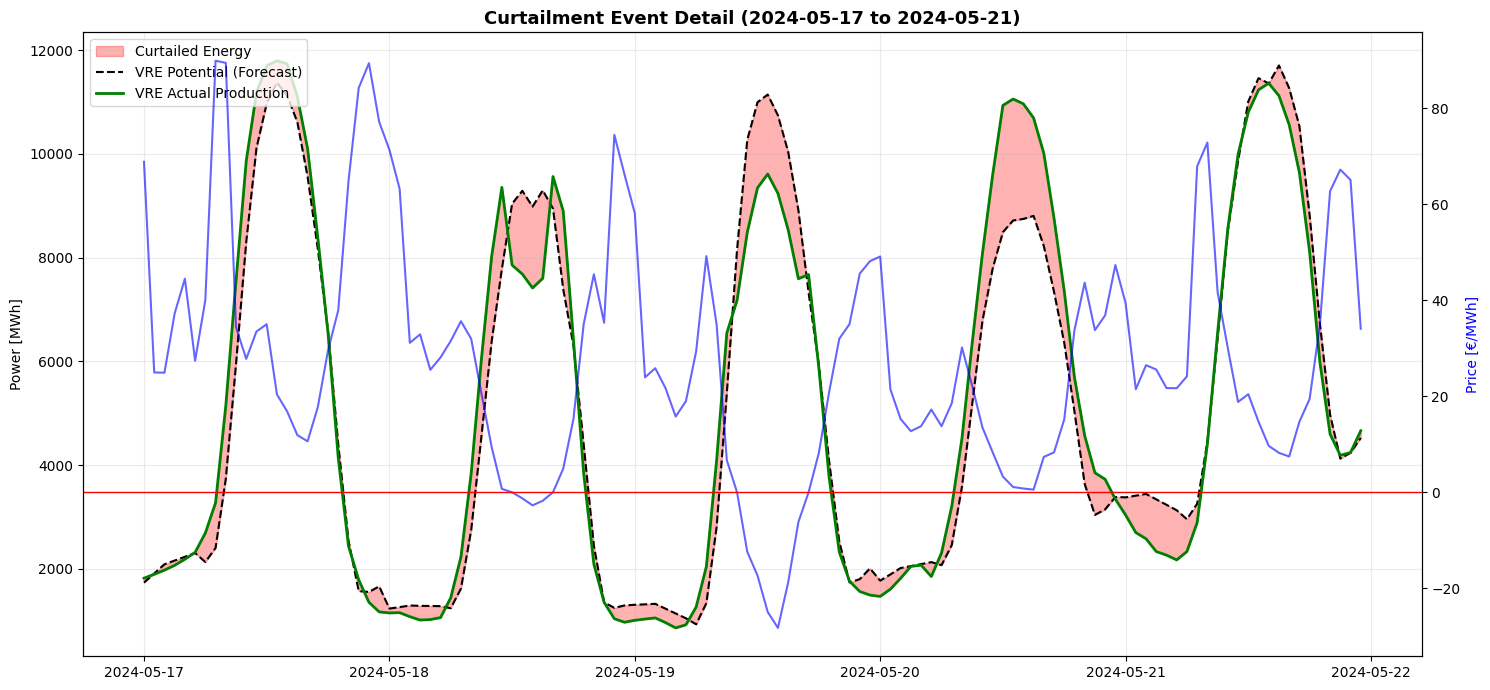

'plots\\curtailment\\france\\curtailment_event_zoom.png'

In [21]:
# 5. Zoom sur un évènement : L'illustration parfaite pour le rapport
# Pentecôte 2024 : week-end prolongé, demande basse + éolien fort
pl.plot_curtailment_event_zoom(df_model, '2024-05-17', '2024-05-21', country=COUNTRY)

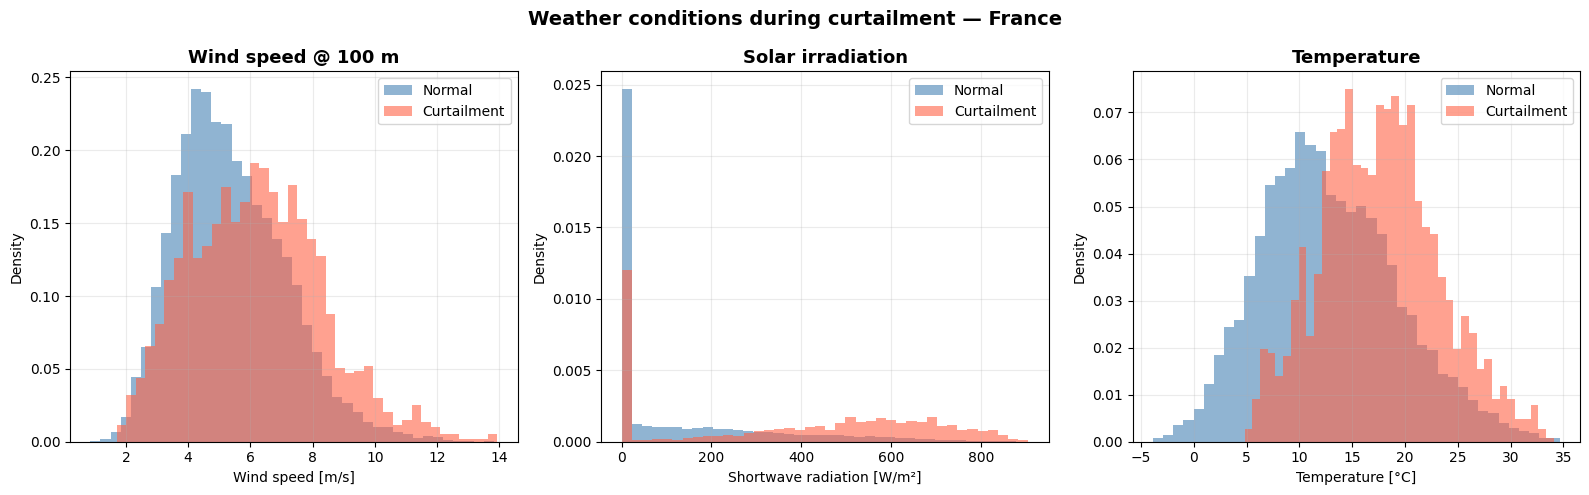

'plots\\curtailment\\france\\weather_curtailment_conditions.png'

In [22]:
# 6. Conditions météo pendant le curtailment vs heures normales
# Répond à : 'Under which conditions?' (météo)
pl.plot_weather_curtailment_conditions(df_model, country=COUNTRY)

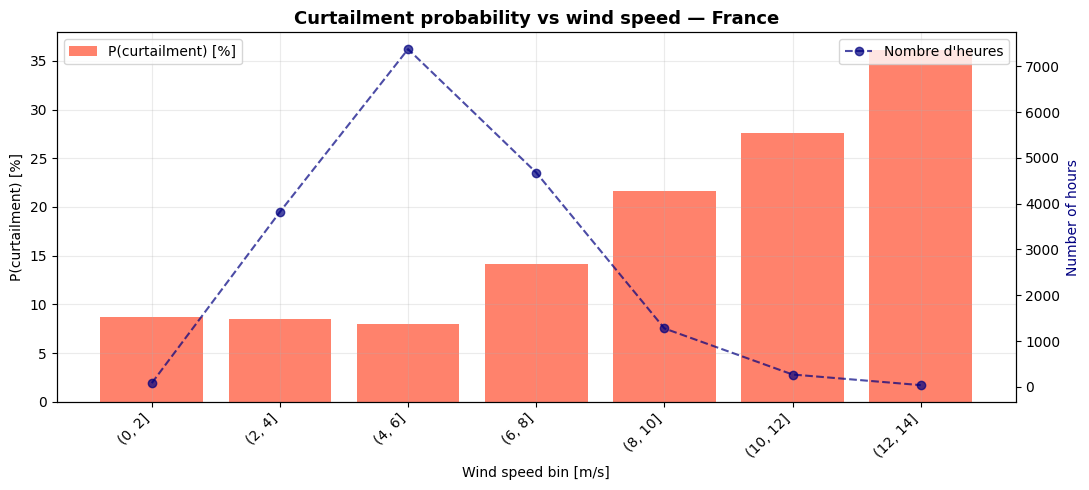

'plots\\curtailment\\france\\curtailment_prob_vs_wind.png'

In [23]:
# 7. Probabilité de curtailment par vitesse de vent (bins de 2 m/s)
# Répond à : 'Under which conditions?' et 'For which renewables?'
pl.plot_curtailment_prob_by_wind(df_model, country=COUNTRY)

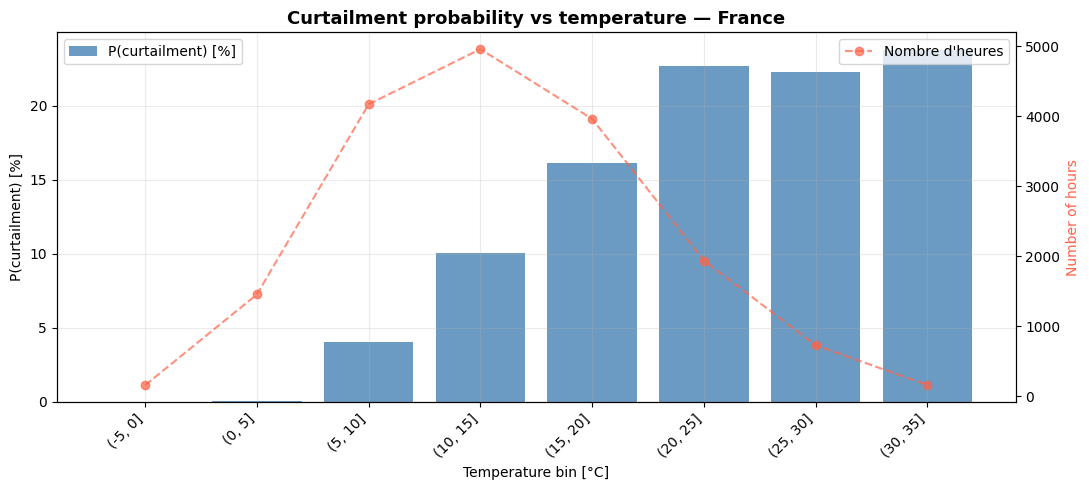

'plots\\curtailment\\france\\curtailment_prob_vs_temperature.png'

In [24]:
# 8. Probabilité de curtailment par tranche de température (5°C)
pl.plot_curtailment_prob_by_temperature(df_model,  country=COUNTRY)

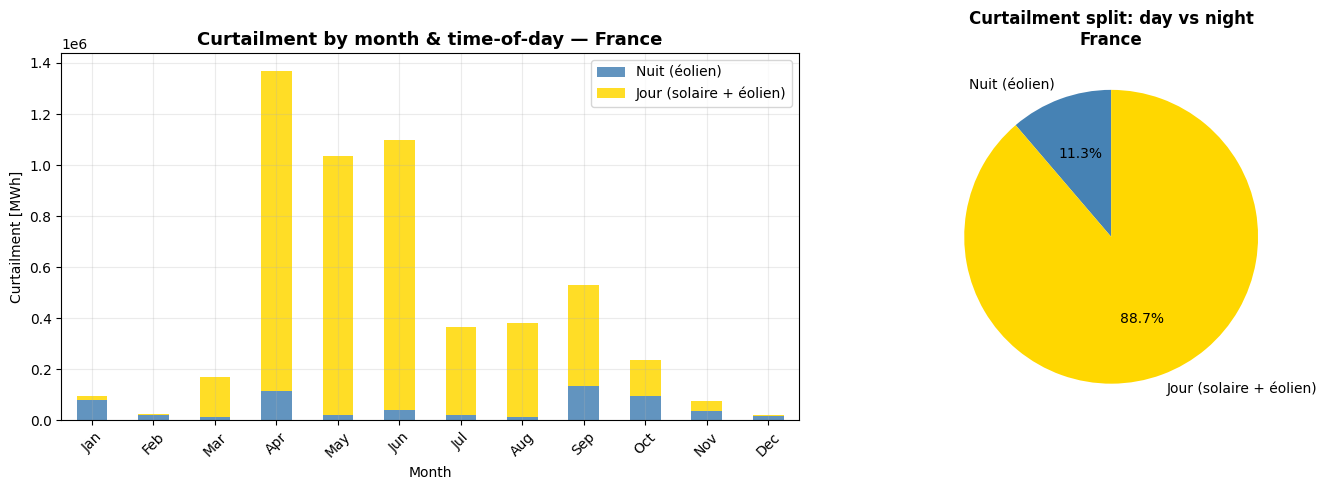

'plots\\curtailment\\france\\curtailment_by_renewable_type.png'

In [25]:
# 9. Décomposition jour/nuit par mois (proxy éolien vs solaire)
# Répond à : 'For which renewables?'
pl.plot_curtailment_by_renewable_type(df_model, country=COUNTRY)

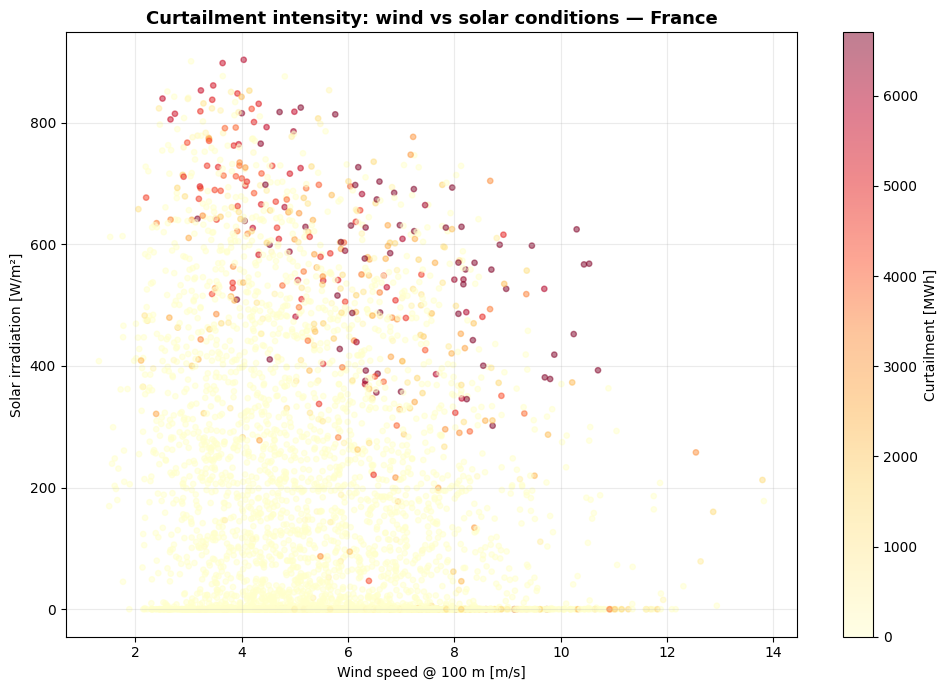

'plots\\curtailment\\france\\curtailment_wind_solar_map.png'

In [26]:
# 10. Carte 2D vitesse vent × rayonnement solaire, colorée par intensité du curtailment
pl.plot_curtailment_wind_solar_scatter(df_model,  country=COUNTRY)

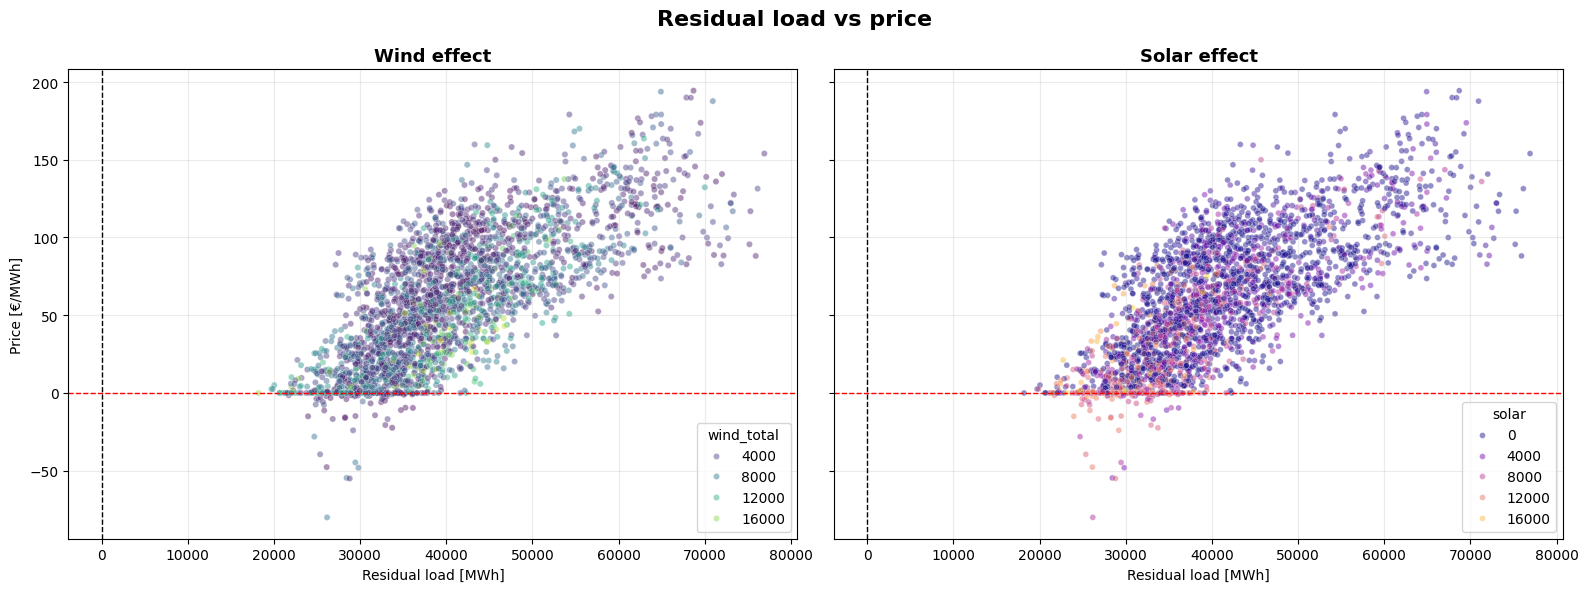

'plots\\curtailment\\france\\residual_load_vs_price.png'

In [27]:
# Analyse offre/demande
pl.plot_residual_load_vs_price(df_model, country=COUNTRY)

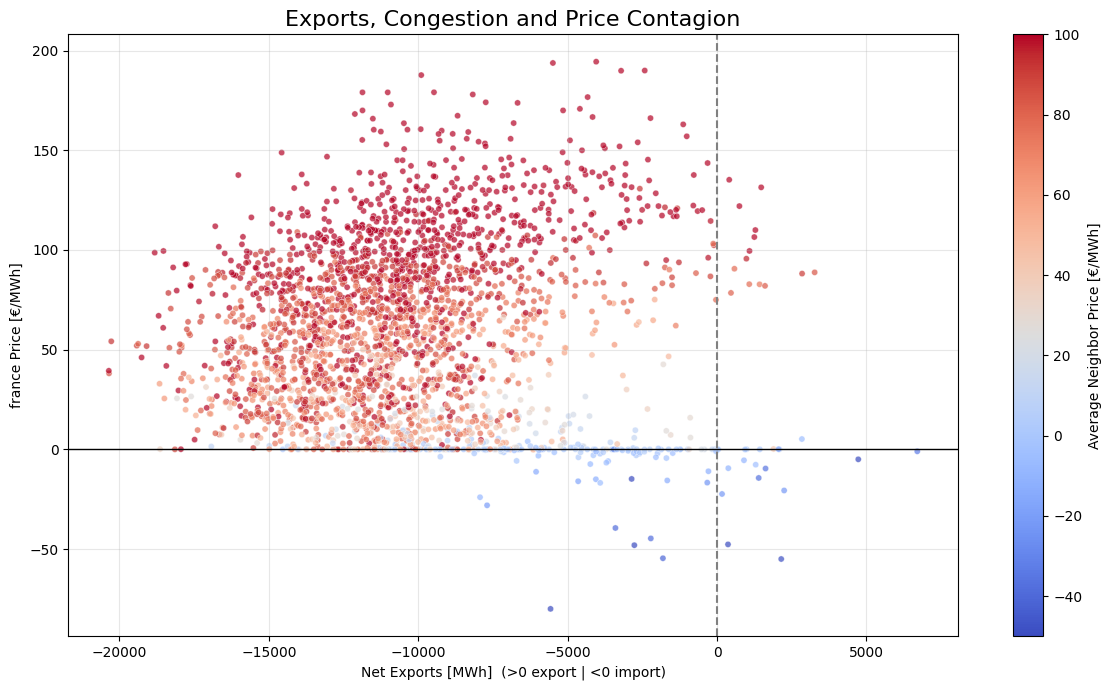

'plots\\curtailment\\france\\exports_and_price.png'

In [28]:
pl.plot_export_congestion_analysis(df_model, country=COUNTRY)

In [29]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

def generate_load_following_table(df_input):
    """
    Reproduit la Table 1 : Estimation du Load-Following nucléaire.
    """
    df = df_input.copy()
    
    # --- 1. Préparation des Variables (Conversion en GW pour correspondre à l'article) ---
    # Nh : Output nucléaire
    df['Nh'] = df['nuclear'] / 1000
    
    # RESh : Solaire + Éolien
    df['RESh'] = (df['wind_total'] + df['solar']) / 1000
    
    # RDh : Demande résiduelle (hors vent/solaire)
    # Formule : Conso + Exports - Hydro - Biomasse
    # Note : Vérifiez si votre 'load' inclut déjà le pompage.
    df['RDh'] = (df['load'] + df['net_export_total'] - 
                 (df['hydro_ror'] + df['hydro_res'] + df['hydro_pumped']) - 
                 df['biomass']) / 1000

    # --- 2. Création des Bins (RDh - RESh) ---
    df['net_res_sys'] = df['RDh'] - df['RESh']
    
    # Définition des seuils en GW : <25, 25-40, 40-63, >63
    bins = [-np.inf, 25, 40, 63, np.inf]
    labels = ['bin_lt25', 'bin_25_40', 'bin_40_63', 'bin_gt63']
    df['bin_status'] = pd.cut(df['net_res_sys'], bins=bins, labels=labels)

    # --- 3. Création des Identifiants pour Effets Fixes (FE) ---
    # Week-of-sample FE (ex: 2024-W12)
    df['week_fe'] = df.index.to_period('W').astype(str)
    # Day-of-sample FE (ex: 2024-03-21)
    df['day_fe'] = df.index.date.astype(str)
    # Groupe pour le clustering des erreurs (par jour)
    df['cluster_group'] = df.index.date

    # --- 4. Définition des Modèles ---
    
    # Spécification (1) : Linéaire simple
    # Col 1: No FE, Col 2: Week FE, Col 3: Day FE
    formulas_eq1 = [
        "Nh ~ RESh + RDh",
        "Nh ~ RESh + RDh + C(week_fe)",
        "Nh ~ RESh + RDh + C(day_fe)"
    ]
    
    # Spécification (2) : Binned (Interaction)
    # On utilise "0 +" pour avoir les coefficients par bin et l'intercept par bin
    # Col 4: No FE, Col 5: Week FE, Col 6: Day FE
    formulas_eq2 = [
        "Nh ~ 0 + bin_status + bin_status:RESh + bin_status:RDh",
        "Nh ~ 0 + bin_status + bin_status:RESh + bin_status:RDh + C(week_fe)",
        "Nh ~ 0 + bin_status + bin_status:RESh + bin_status:RDh + C(day_fe)"
    ]

    results = []

    # --- 5. Exécution des régressions ---
    print("Running regressions (this may take a minute with Day-of-sample FE)...")
    
    for i, form in enumerate(formulas_eq1 + formulas_eq2):
        print(f"Estimating Model ({i+1})...")
        # Clustering par jour pour les erreurs-types robustes
        model = smf.ols(formula=form, data=df).fit(
            cov_type='cluster', 
            cov_kwds={'groups': df['cluster_group']}
        )
        results.append(model)

    # --- 6. Affichage Synthétique (Exemple de formatage) ---
    # Note : Pour un rendu parfait comme dans l'article, on extrait les coefs
    summary_data = {
        "Variable": ["RESh", "RDh", "RESh:bin<25", "RDh:bin<25", "RESh:bin25-40", "RDh:bin25-40"],
    }
    
    for i, res in enumerate(results):
        col_name = f"({i+1})"
        # Extraction simplifiée pour l'exemple
        summary_data[col_name] = [
            f"{res.params.get('RESh', 0.0):.3f}" if i < 3 else "-",
            f"{res.params.get('RDh', 0.0):.3f}" if i < 3 else "-",
            f"{res.params.get('bin_status[bin_lt25]:RESh', 0.0):.3f}" if i >= 3 else "-",
            f"{res.params.get('bin_status[bin_lt25]:RDh', 0.0):.3f}" if i >= 3 else "-",
            f"{res.params.get('bin_status[bin_25_40]:RESh', 0.0):.3f}" if i >= 3 else "-",
            f"{res.params.get('bin_status[bin_25_40]:RDh', 0.0):.3f}" if i >= 3 else "-",
        ]

    table_final = pd.DataFrame(summary_data)
    
    # Ajout des stats de base en bas de table
    fe_row = ["Week FE", "N", "Y", "N", "N", "Y", "N"]
    day_fe_row = ["Day FE", "N", "N", "Y", "N", "N", "Y"]
    r2_row = ["R2"] + [f"{res.rsquared:.3f}" for res in results]
    obs_row = ["Observations"] + [f"{int(res.nobs):,}" for res in results]
    
    print("\n--- REPRODUCTION DE LA TABLE 1 ---")
    print(table_final.to_string(index=False))
    print("-" * 50)
    print(f"{' '.join(fe_row)}")
    print(f"{' '.join(day_fe_row)}")
    print(f"{' '.join(r2_row)}")
    print(f"{' '.join(obs_row)}")

    return results

# Utilisation :
df_model['load'] = df_model['load'].interpolate(method='linear', limit=2)
results = generate_load_following_table(df_model)

Running regressions (this may take a minute with Day-of-sample FE)...
Estimating Model (1)...
Estimating Model (2)...
Estimating Model (3)...
Estimating Model (4)...
Estimating Model (5)...
Estimating Model (6)...

--- REPRODUCTION DE LA TABLE 1 ---
     Variable    (1)    (2)    (3)    (4)    (5)    (6)
         RESh -0.475 -0.359 -0.290      -      -      -
          RDh  0.360  0.073 -0.005      -      -      -
  RESh:bin<25      -      -      - -0.471 -0.458 -0.355
   RDh:bin<25      -      -      -  0.317  0.128  0.011
RESh:bin25-40      -      -      - -0.461 -0.251 -0.136
 RDh:bin25-40      -      -      -  0.462  0.073 -0.005
--------------------------------------------------
Week FE N Y N N Y N
Day FE N N Y N N Y
R2 0.420 0.785 0.913 0.435 0.790 0.917
Observations 17,538 17,538 17,538 17,538 17,538 17,538
